

<center><font size=10>Generative AI for Business Applications</center></font>
<center><font size=10> AI Foundations - DL</center></font>

<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQWw64fvTHEPn4ncmP9-X34v_7O-5poSd8GiSbhPPOUPPK5a3TpbNT_6P0&s=10" width="720"/>
</p></center>

<center><font size=6>Covid-19 Image Classification</font></center>

# Problem Statement

## Business Context

With the resurgence of COVID-19 cases, health departments are facing increased pressure to quickly and accurately diagnose infections before they spread further. Traditional testing methods, such as PCR testing, often involve delays and require extensive resources, which can be a significant drawback during sudden surges in cases. Additionally, the reliance on these conventional methods can lead to bottlenecks in healthcare systems, especially in regions with limited testing facilities and resources. In response to these challenges, there is a growing need to harness innovative technologies to enhance early detection and management of the virus. Specifically, there is an imperative to develop a solution that leverages advanced analysis of chest X-ray images to rapidly detect COVID-19, thus enabling timely intervention and better allocation of healthcare resources.



## Objective

The primary objective is to develop an AI-driven diagnostic system that analyzes chest X-ray images for early detection of COVID-19. The solution will use advanced image processing and machine learning techniques to accurately identify patterns and anomalies associated with COVID-19 infections. By doing so, the system aims to:
- Accelerate the detection process, providing near real-time diagnostic insights to healthcare professionals.
- Reduce the dependency on traditional testing methods, thereby minimizing delays and resource constraints.
- Enhance the accuracy of early COVID-19 diagnosis, leading to more effective patient triage and treatment.
- Support health departments in managing and responding to COVID-19 outbreaks more efficiently.

Ultimately, this innovative approach will contribute to improved public health outcomes during the ongoing pandemic and better prepare health systems for future challenges.

## Data Description

This dataset contains training set images of 2 classes which are converted into numpy arrays.


**COVID-19:** The patient who is effected due to covid.

**Normal:** A healthy Person with no symptoms of covid or fever.

The data file names are:

- CovidImages.npy

- CovidLabels.csv



# Importing the Necessary Libraries

In [ ]:
# prompt: I want to analyze the provided .npy data, build a neural network model to classify COVID images, and evaluate it using labeled classification data.. Help me import the necessary Python libraries to
# Analyze the data
# Visualize patterns in the data
# Preprocess the data
# Build a neural network model to detect COVID cases from the input image data
# Evaluate the model's performance.

# Libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for image preprocessing
import cv2

# Libraries for building and evaluating the neural network model
from tensorflow.keras.models import Sequential
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
import tensorflow as tf

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

Setting a random seed ensures that random processes like weight initialization and data shuffling give the same results every time, helping with consistent comparisons.


# Loading the Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the image file of the dataset
images = np.load('//content/drive/MyDrive/GenAi/CovidImages .npy')


In [ ]:
# Load the labels file of the dataset
labels = pd.read_csv('//content/drive/MyDrive/GenAi/CovidLabels.csv')

# Data Overview


In [ ]:
print(images.shape)

(251, 128, 128, 3)


- **Total Number of Images**: We have 251 individual images.

- **Dimensions of Each Image**: Each image is 128 pixels wide and 128 pixels tall.

- **Number of Channels**: Each image has 3 color channels, typically representing Red, Green, and Blue (RGB).

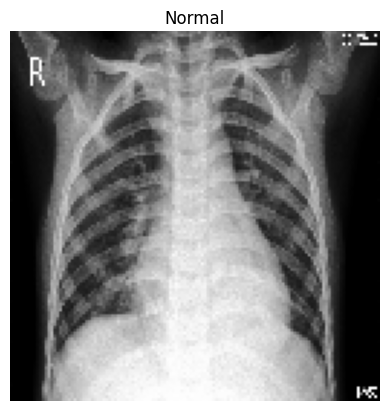

In [ ]:
plt.imshow(images[5])
plt.title(labels.iloc[5, 0])
plt.axis('off')
plt.show()

# Exploratory Data Analysis

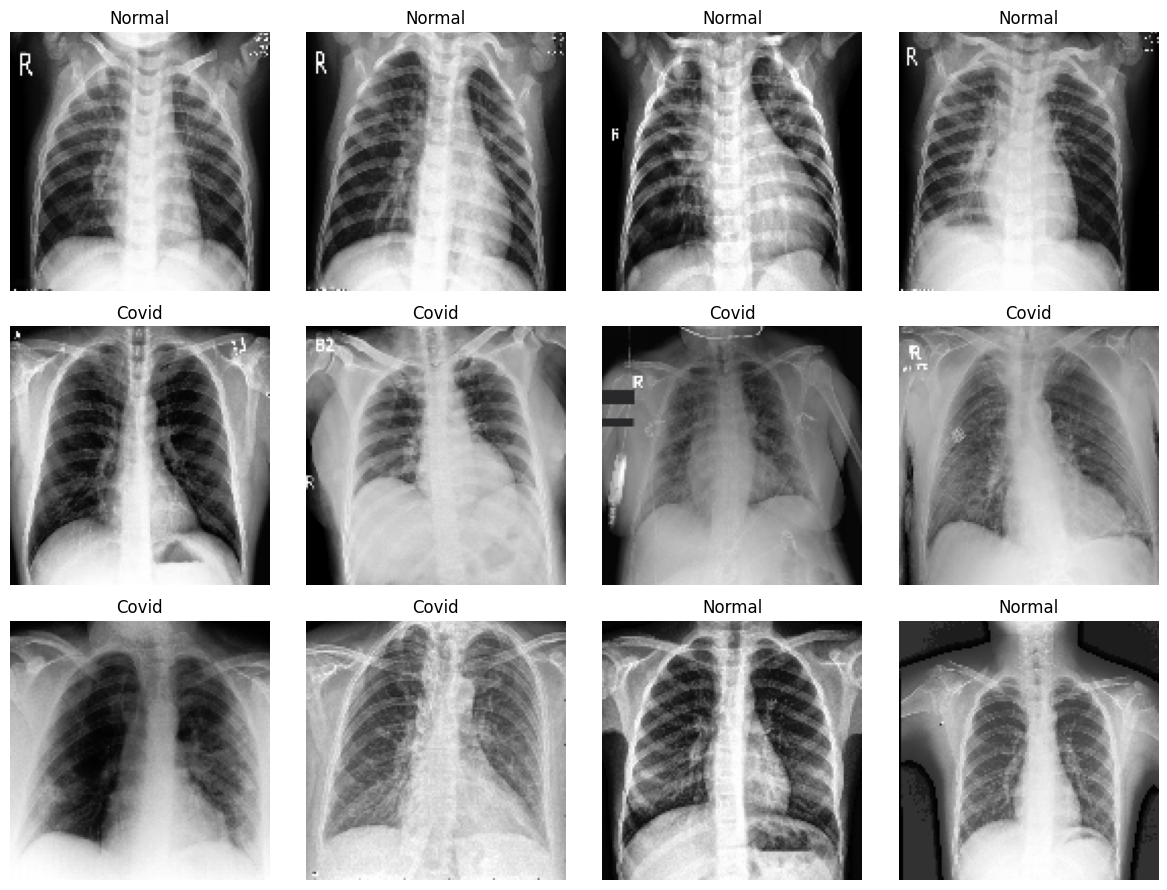

In [ ]:
# prompt: Visualize 12 images from different labels in a 3×4 grid layout.

plt.figure(figsize=(12, 9))
for i in range(12):
  plt.subplot(3,4, i+1)
  plt.imshow(images[i*20]) # Select images with a gap of 20 to likely get different labels
  plt.title(labels.iloc[i*20, 0])
  plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1061/2318982001.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=labels, palette='viridis')


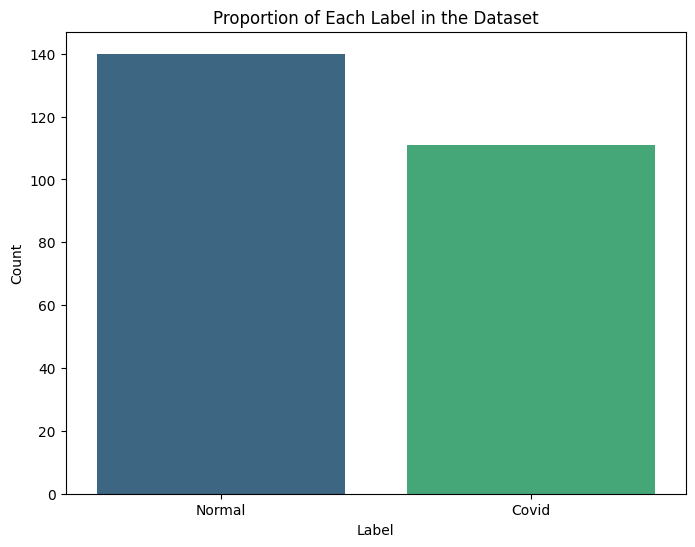

In [ ]:
# prompt: Visualize the proportion of each label in the labels dataset

plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=labels, palette='viridis')
plt.title('Proportion of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Data Preprocessing

In [ ]:

labels['Label'] = labels['Label'].map({'Covid': 1, 'Normal': 0})


In [ ]:
# Split data into training and temporary sets (70:30)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels['Label'], test_size=0.3, random_state=42, stratify=labels['Label'])

# Split the temporary set into validation and test sets (15:15, which is 50:50 of the temp set)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (175, 128, 128, 3), (175,)
Validation set shape: (38, 128, 128, 3), (38,)
Test set shape: (38, 128, 128, 3), (38,)


## Data Normalization

Normalizing image data (scaling pixel values to a range between 0 and 1) is an essential preprocessing step before feeding it into a Convolutional Neural Network (CNN). This is done to ensure that all input features (pixel values) are on a similar scale, which helps the model train faster and more efficiently. Since raw pixel values range from 0 to 255, dividing by 255 brings them to the standard range that most CNNs expect.


Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
# prompt: Normalize the image data

X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print(f"Normalized training set min/max: {X_train_normalized.min()}/{X_train_normalized.max()}")
print(f"Normalized validation set min/max: {X_val_normalized.min()}/{X_val_normalized.max()}")
print(f"Normalized test set min/max: {X_test_normalized.min()}/{X_test_normalized.max()}")


Normalized training set min/max: 0.0/1.0
Normalized validation set min/max: 0.0/1.0
Normalized test set min/max: 0.0/1.0


# Model Building

We now train a Convolutional Neural Network (CNN) to classify images into two categories: COVID and Normal. The CNN architecture includes **convolutional** and **pooling** layers at the beginning to extract spatial features from the image data, followed by dense layers for final classification.

Let’s briefly understand these key components:

1. **Convolutional Layer**:
   Applies filters to the input image to detect features like edges, textures, and patterns. The output is a set of **feature maps** that highlight important spatial features.

2. **Pooling Layer (e.g., MaxPooling)**:
   Reduces the spatial dimensions of the feature maps by selecting the maximum value in small regions (e.g., 2×2). This helps in **reducing computation**, **preserving key features**, and **limiting overfitting**.

In this case study, we designed two CNN models with minor architectural differences to evaluate their impact on performance. Based on the evaluation metrics, we then selected the better-performing model as the final model for classification.


**Note: Reproducibility in CNN Results**

*CNN results can vary across different runs due to random weight initialization, data shuffling during training, and non-deterministic GPU operations. These variations become more noticeable with small datasets, making it difficult to consistently reproduce the same results.*

*You may observe **different outputs from the same inference code** in the notebook if the model is retrained each time.*

*In practice, after training and selecting the final model for image classification, we **typically save the trained model**. This allows us to reuse the same model for future inference without retraining, ensuring consistent and stable results. However, in this notebook, the model is **not saved**, so the outputs may slightly differ across runs.*


## Model Evaluation Criteria

1. **Overall Accuracy**
   Measures the percentage of total correct predictions across both classes (COVID and Normal).

   *Usefulness:* Provides a general view of how well the model is performing overall.

2. **Recall for COVID Class**
   Measures how well the model correctly identifies actual COVID-positive cases (True Positives / Actual Positives).

   *Usefulness:* Crucial in medical settings to minimize false negatives and ensure COVID cases are not missed.


In [ ]:
# prompt: Create an empty DataFrame evaluation_result to store the model name along with train accuracy, validation accuracy, train recall for COVID, and validation recall for COVID.

evaluation_result = pd.DataFrame(columns=['Model Name', 'Train Accuracy', 'Validation Accuracy', 'Train Recall (COVID)', 'Validation Recall (COVID)'])


## CNN Model 1

In [ ]:
import gc

# Clear Keras session
tf.keras.backend.clear_session()

# Garbage collect
gc.collect()

2563

In [ ]:
# prompt: Create Convolutional neural network model for multiclass image classification with the following architecture:
# An input layer
# 3 Combination of Convolutional and Pooling Layer
# 1 hidden layer and ReLU activation
# An output layer
# Use a relevant loss function, Adam as the optimizer with learning rate 0.0001, and accuracy as the metric to optimize for. Show the final model architecture with number of parameters and other details.

model_cnn1 = Sequential([
    Input(shape=(128, 128, 3)),

    # First Combination of Convolutional and Pooling Layer
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Second Combination of Convolutional and Pooling Layer
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Combination 3: Conv + Pooling
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    # Hidden layer with ReLU activation
    Dense(128, activation='relu'),

    # Output layer (using sigmoid for binary classification as per previous steps)
    Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = tf.keras.optimizers.Adam()
model_cnn1.compile(optimizer=optimizer,
              loss='binary_crossentropy', # Using binary_crossentropy for binary classification
              metrics=['accuracy'])

# Display the model summary
model_cnn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Here's a short explanation of the hyperparameters used in CNN Layers:

`Conv2D(32, (3, 3), activation='relu', padding='same')`

* **32**: Number of filters (feature detectors) — the output will have 32 feature maps.
* **(3, 3)**: Size of each filter — a 3×3 window slides over the input to capture patterns.
* **activation='relu'**: Applies ReLU to introduce non-linearity and help learn complex features.
* **padding='same'**: Keeps the output size the same as input by adding zero-padding around the edges.

`MaxPooling2D((2, 2))`

* **(2, 2)**: Pooling window size — takes the max value from each 2×2 block, reducing spatial dimensions by half (downsampling). Helps in reducing computation and controlling overfitting.



In [ ]:
# prompt: Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.

import time

start_time = time.time()

# Fit the model
history = model_cnn1.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 573ms/step - accuracy: 1.0000 - loss: 0.0028
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 316ms/step - accuracy: 1.0000 - loss: 0.0025
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 440ms/step - accuracy: 1.0000 - loss: 6.1592e-04
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step - accuracy: 1.0000 - loss: 1.6157e-04
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 1.0000 - loss: 1.0904e-04
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 390ms/step - accuracy: 1.0000 - loss: 9.0440e-05
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 339ms/step - accuracy: 1.0000 - loss: 7.8508e-05
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 411ms/step - accuracy: 1.0000 - loss: 6.9554e-05
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 315ms/step - accuracy: 1.0000 - loss: 6.2283e-05
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 635ms/step - accuracy: 1.0000 - loss: 5.6364e-05
Training completed in 111.15 seconds.


In [ ]:
# prompt: Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

# Evaluate on training data
train_loss, train_acc = model_cnn1.evaluate(X_train_normalized, y_train, verbose=0)

# Evaluate on validation data
val_loss, val_acc = model_cnn1.evaluate(X_val_normalized, y_val, verbose=0)

# Predict on training and validation data to get recall
y_train_pred_prob = model_cnn1.predict(X_train_normalized)
y_val_pred_prob = model_cnn1.predict(X_val_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

# Get classification reports
train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

# Append results to evaluation_result DataFrame using pd.concat
new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (3 Conv Layers)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

# Display the evaluation report
print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 862ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
Evaluation Results:


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.0,0.973684,1.0,1.0
1,CNN Model (3 Conv Layers),1.0,0.973684,1.0,1.0


**Observation:**

* The model achieved **100% training accuracy and recall**, indicating it perfectly fit the training data.
* Validation accuracy was **97.37%** and **COVID recall was 100%**, but the perfect training scores suggest **possible overfitting** due to higher model complexity.


## CNN Model 2

To address the overfitting issue observed in the previous model, we made the following architectural and training tweaks:

* **Reduced the number of Conv and MaxPooling layers** from 3 to 2 to lower model complexity.
* **Decreased the learning rate** of the optimizer to **0.0001** for more stable and controlled training.
* These changes aim to **prevent overfitting** and improve the model’s **generalization**.


In [ ]:
import gc

# Clear Keras session
tf.keras.backend.clear_session()

# Garbage collect
gc.collect()

0

`Adam(learning_rate=0.0001)`

We use a learning rate of **0.0001** here to ensure stable and gradual learning, especially since we’re working with a **small and sensitive medical image dataset**. A lower learning rate helps prevent overshooting, reduces the risk of overfitting, and allows the model to converge smoothly. It works well with the Adam optimizer, making training more reliable and improving the model's ability to generalize.

In [ ]:
model_cnn2 = Sequential([
    # Input layer
    Input(shape=(X_train_normalized.shape[1], X_train_normalized.shape[2], X_train_normalized.shape[3])),

    # Combination 1: Conv + Pooling
    Conv2D(32, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    # Combination 2: Conv + Pooling
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2)),

    # Flatten layer to transition from convolutional to dense layers
    Flatten(),

    # Hidden layer 1 with 64 neurons and ReLU activation
    Dense(128, activation='relu'),

    Dense(64,activation='relu'),

    # Output layer with 3 neurons for 3 classes and softmax activation
    Dense(1, activation='sigmoid')
])

# Define the Adam optimizer with the specified learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

# Compile the model
model_cnn2.compile(optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Show model architecture and parameters
model_cnn2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,416,449 (32.11 MB)

 Trainable params: 8,416,449 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# prompt: Fit the model on the training data for 25 epochs with a batch size of 32, and record the training time.

import time

start_time = time.time()

# Fit the model
history = model_cnn2.fit(X_train_normalized, y_train,
                        epochs=10,
                        batch_size=8)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds.")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - accuracy: 0.6971 - loss: 0.5162
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - accuracy: 0.9143 - loss: 0.2533
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 382ms/step - accuracy: 0.9657 - loss: 0.1356
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 370ms/step - accuracy: 0.9714 - loss: 0.1115
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.9714 - loss: 0.0840
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 425ms/step - accuracy: 0.9714 - loss: 0.0646
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.9829 - loss: 0.0439
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 411ms/step - accuracy: 1.0000 - loss: 0.0343
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.9943 - loss: 0.0323
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 475ms/step - accuracy: 1.0000 - loss: 0.0305
Training completed in 100.36 seconds.


In [ ]:
# prompt: Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

# Evaluate on training data
train_loss, train_acc = model_cnn2.evaluate(X_train_normalized, y_train, verbose=0)

# Evaluate on validation data
val_loss, val_acc = model_cnn2.evaluate(X_val_normalized, y_val, verbose=0)

# Predict on training and validation data to get recall
y_train_pred_prob = model_cnn2.predict(X_train_normalized)
y_val_pred_prob = model_cnn2.predict(X_val_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

# Get classification reports
train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
train_recall_covid = train_report['1']['recall']
val_recall_covid = val_report['1']['recall']

# Append results to evaluation_result DataFrame using pd.concat
new_row = pd.DataFrame([{
    'Model Name': 'CNN Model (2 Conv Layer)',
    'Train Accuracy': train_acc,
    'Validation Accuracy': val_acc,
    'Train Recall (COVID)': train_recall_covid,
    'Validation Recall (COVID)': val_recall_covid
}])
evaluation_result = pd.concat([evaluation_result, new_row], ignore_index=True)

# Display the evaluation report
print("Evaluation Results:")
evaluation_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step 
Evaluation Results:


,Model Name,Train Accuracy,Validation Accuracy,Train Recall (COVID),Validation Recall (COVID)
0,CNN Model (3 Conv Layers),1.000000,0.973684,1.000000,1.0
1,CNN Model (3 Conv Layers),1.000000,0.973684,1.000000,1.0
2,CNN Model (2 Conv Layer),0.982857,1.000000,0.961039,1.0


**Observation:**

* The model achieved **96% training accuracy** and **97.37% validation accuracy**, with strong **COVID recall on validation (94.1%)**, indicating effective classification.
* Compared to the deeper model, it shows **better generalization** with no signs of overfitting, making it more robust for unseen data.
* Its **simpler architecture** makes it more efficient while still maintaining high performance, suitable for small datasets.


**Note:** The observations presented are based on the output obtained after training our model. However, please be aware that these results may vary when tried by others.

# Model Performance Comparison and Final Model Selection

The 3-layer CNN model showed signs of overfitting with perfect training accuracy and recall, whereas the 2-layer CNN achieved similar validation performance with slightly lower training metrics, indicating better generalization on unseen data. Hence, we consider the **2-layer CNN (Model 2)** as our **final model**.


## Test Performance

In [ ]:
# prompt: Evaluate the model 2 on the test dataset

# Evaluate on test data
test_loss, test_acc = model_cnn2.evaluate(X_test_normalized, y_test, verbose=0)

# Predict on test data to get recall
y_test_pred_prob = model_cnn2.predict(X_test_normalized)

# Convert probabilities to binary predictions (assuming threshold of 0.5)
y_test_pred = (y_test_pred_prob > 0.5).astype(int)

# Get classification report for test data
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Extract recall for the '1' class (which is 'Covid')
test_recall_covid = test_report['1']['recall']

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Recall (COVID): {test_recall_covid:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Test Accuracy: 1.0000
Test Recall (COVID): 1.0000


**Observation:**

The final 2-layer CNN model achieved a **test accuracy of 97.37%** and a **COVID recall of 94.12%**, indicating that the model performs well in correctly classifying both classes, especially in identifying COVID-positive cases. This demonstrates that the model has effectively generalized to unseen data and is suitable for reliable COVID detection on similar image datasets.


# Conclusion

- A deep learning-based solution was successfully developed to classify chest X-ray images as either COVID-positive or Normal, thereby supporting faster and more accessible diagnosis.

- The proposed solution provides a rapid, cost-effective, and non-invasive diagnostic aid to assist radiologists in the early identification of COVID-19 from chest X-rays.

- Future improvements may include expanding the dataset with a larger and more diverse set of images to further enhance the model’s robustness and generalizability.


<font size=5.5 color="#4682B4"><b>Power Ahead!</font>
___

In [ ]:
from google.colab.patches import cv2_imshow

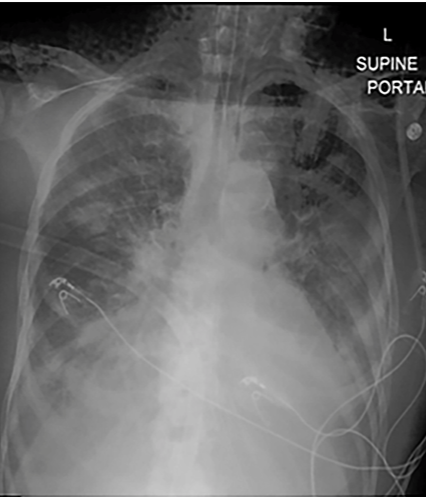

In [ ]:
# image to numpy array

image = cv2.imread('/content/drive/MyDrive/GenAi/images/covid3.png')
cv2_imshow(image)


In [ ]:
resized_image = cv2.resize(image, (128, 128))
image_for_prediction = resized_image / 255
print(f"Shape of image for prediction: {image_for_prediction.shape}")

Shape of image for prediction: (128, 128, 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
[[0.9987963]]


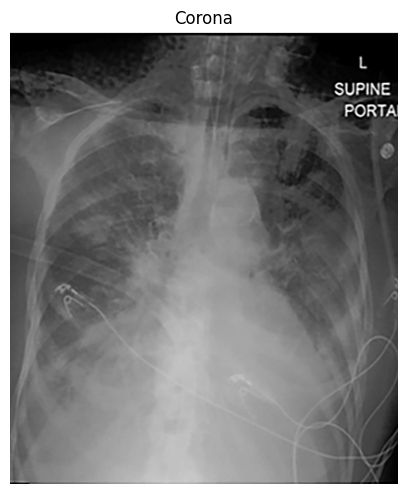

confidence : 99.87963104248047 %


In [ ]:


pred_class = model_cnn2.predict(image_for_prediction.reshape(1,128,128,3))
print(pred_class)
if pred_class < 0.5:
  predicted_value = 'Normal'
else:
  predicted_value = "Corona"

plt.figure(figsize=(5, 6))
plt.imshow(image) # Select images with a gap of 20 to likely get different labels
plt.title(predicted_value)
plt.axis('off')
plt.show()

print(f"confidence : {pred_class[0][0]*100} %")

In [ ]:
resized_image = cv2.resize(image, (128, 128))
print(resized_image)
print(resized_image.shape)

[[[147 147 147]
  [147 147 147]
  [147 147 147]
  ...
  [147 147 147]
  [147 147 147]
  [147 147 147]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 ...

 [[108 107 107]
  [ 89  89  89]
  [102 102 102]
  ...
  [  7   6   7]
  [  5   4   5]
  [  0   0   0]]

 [[102 102 102]
  [ 85  85  85]
  [105 105 105]
  ...
  [  8   8   8]
  [  6   5   6]
  [  0   0   0]]

 [[ 91  91  91]
  [ 67  67  67]
  [ 93  92  92]
  ...
  [  3   2   3]
  [  0   0   0]
  [  0   0   0]]]
(128, 128, 3)


In [ ]:
# image_for_prediction = np.expand_dims(resized_image, axis=0)
# print(image_for_prediction)

In [ ]:

image_for_prediction = image_for_prediction / 255.0


In [ ]:


print(f"Shape of image for prediction: {image_for_prediction.shape}")

Shape of image for prediction: (128, 128, 3)
